# Daten einlesen und ersten Überblick bekommen 

In [1]:
import pandas as pd
import os

base_path = "/datasets/multi-view-pig-posture-recognition"

# Laden der Trainingsdaten
train1_df = pd.read_csv(os.path.join(base_path, 'train1.csv'))
train2_df = pd.read_csv(os.path.join(base_path, 'train2.csv'))

train_df = pd.concat([train1_df, train2_df], ignore_index=True)

print(train_df.head())

<jemalloc>: Unsupported system page size


                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   
2  train_pen1_orb_cam1_20250108_085204_0002   
3  train_pen1_orb_cam1_20250108_085204_0003   
4  train_pen1_orb_cam1_20250108_085204_0004   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
2  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
3  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
4  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  
2   [732.0,137.5,342.0,198.0]         1  
3   [830.0,169.0,370.0,263.0]         0  
4   [611.5,314.8,381.5,386.6]         3  


In [2]:
# Zeigt alle Spaltennamen an
print("Spalten im Dataframe:", train_df.columns.tolist())

print("\nInhalt der ersten Zeile:")
print(train_df.iloc[0])

Spalten im Dataframe: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']

Inhalt der ersten Zeile:
row_id      train_pen1_orb_cam1_20250108_085204_0000
image_id           pen1_orb_cam1_20250108_085204.jpg
width                                           1920
height                                          1080
bbox                      [1031.5,368.0,349.0,435.0]
class_id                                           0
Name: 0, dtype: object


In [3]:
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
train2_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


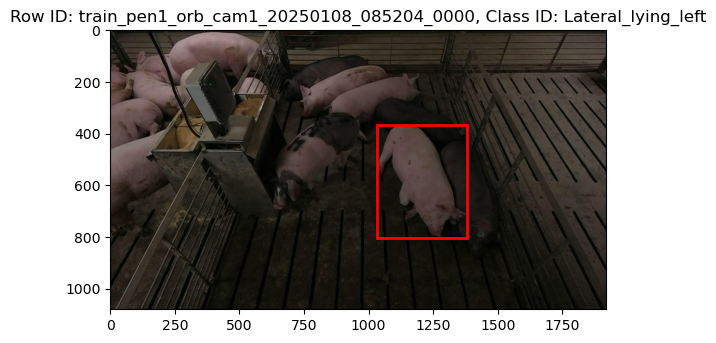

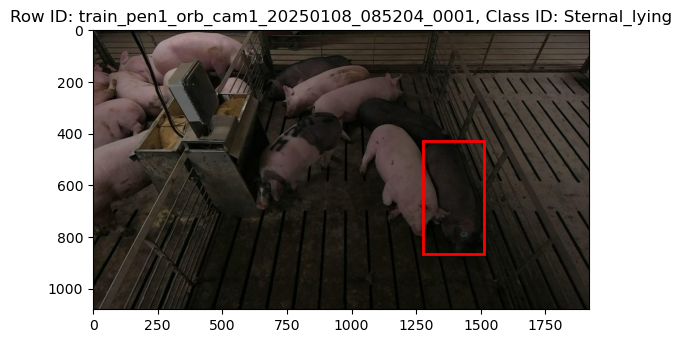

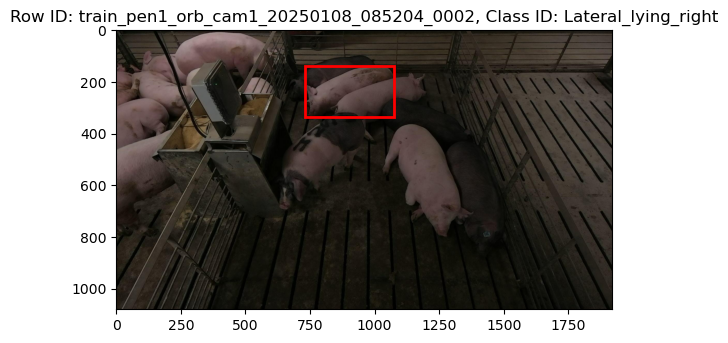

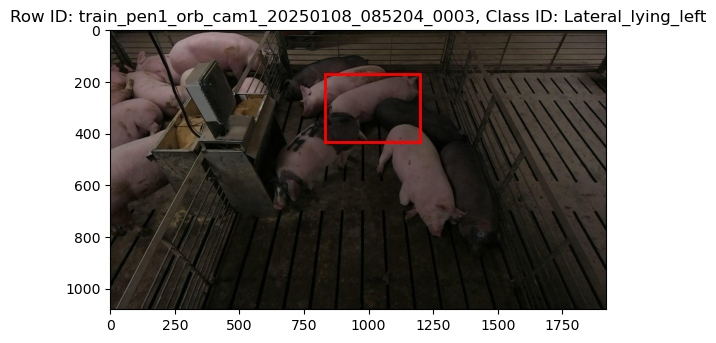

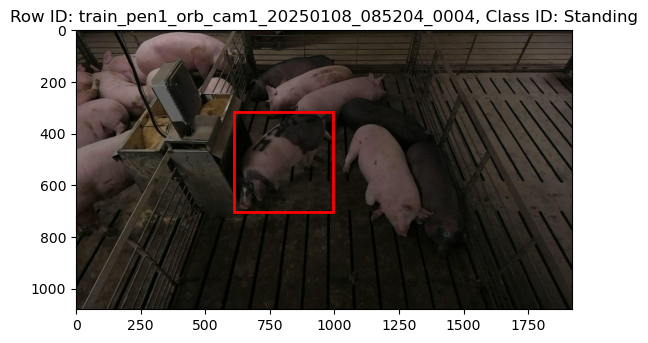

In [5]:
# data paths
train1_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_path = "/datasets/multi-view-pig-posture-recognition/test_images"
# csv path with row_id, image_id, width, height, bbox, class_id
train1_csv = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv = "/datasets/multi-view-pig-posture-recognition/test.csv"
# pig posture classes
pig_posture_classes = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying"
}

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
train1 = pd.read_csv(train1_csv)
train2 = pd.read_csv(train2_csv)
test = pd.read_csv(test_csv)
#show the first 5 rows of train1 paired with their images and their bboxes drawn on the images
for i in range(5):
    row = train1.iloc[i]
    image_id = row["image_id"]
    image_path = f"{train1_path}/{image_id}"
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(f"Row ID: {row['row_id']}, Class ID: {pig_posture_classes[row['class_id']]}")
    # draw the bbox on the image
    bbox = eval(row["bbox"])
    x, y, w, h = bbox
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
    plt.show()